# Image Classification with Transformers
### Authors: Cole Drumheller and Joseph Doty

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import optuna

/home/dsu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 1337
torch.manual_seed(seed)

# Hyperparameters

img_size = 32            # CIFAR-10 images are 32x32
patch_size = 4        # 4x4 patches -> (32/4)^2 = 64 tokens | 2x2 patches = 256 tokens | 8x8 patches = 16 tokens
in_chans = 3
num_classes = 10

# model capacity
embed_dim = 192
num_heads = 6
mlp_ratio = 4
num_layers = 6
dropout = 0.1

# training
batch_size = 128
epochs = 15
lr = 3e-4
weight_decay = 0.05

# misc
save_dir = "./vit_cifar"
os.makedirs(save_dir, exist_ok=True)

In [27]:

# Data: CIFAR-10
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    #T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)), original weights
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = T.Compose([
    T.ToTensor(),
    #T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_ds = torchvision.datasets.CIFAR10(root=".", train=True, download=True, transform=transform_train)
test_ds = torchvision.datasets.CIFAR10(root=".", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [28]:

# ViT components
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_chans, embed_dim):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        # Use a conv layer to produce patch embeddings
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)                # (B, embed_dim, H/ps, W/ps)
        x = x.flatten(2)                # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)           # (B, num_patches, embed_dim)
        return x

In [29]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, in_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

The below code was added as part of the expanding attention project
- Edited by Cole Drumheller

In [30]:
# function to add a window mask: smaller in early layers, global at end layers
def get_attention_mask(num_tokens, layer, num_layers, grid_size):
    # current window size is a fraction of the whole image grid
    max_window = grid_size # can't be larger than the image
    min_window = 4 # start small
    current_window = int(min_window + (layer / (num_layers-1)) * (max_window-min_window))
    num_tokens = int(num_tokens)
    mask = torch.zeros([num_tokens, num_tokens])
    for i in range(num_tokens):
        # convert index to 2D coords
        y, x = divmod(i, grid_size)
        for j in range(num_tokens):
            y2, x2 = divmod(j, grid_size)
            # Only allow attention inside the current_window radius
            if abs(y-y2) <= current_window // 2 and abs(x-x2) <= current_window // 2:
                mask[i,j] = 1
    return mask

Below code cell was modified to include expanding attention
- Edited made by Cole Drumheller

In [31]:
class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, dropout=0.0, layer_id=0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x, return_attn=False, layer_id=0):
        B, N, C = x.shape
        qkv = self.qkv(x)                      
        qkv = qkv.reshape(B, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)       
        q, k, v = qkv[0], qkv[1], qkv[2] # extract the query, key, and value matrices

        attn = (q @ k.transpose(-2, -1)) * self.scale
        ### Modified for expanding attention project
        num_patches = math.pow((img_size // patch_size), 2) + 1
        # get the mask
        mask = get_attention_mask(num_patches, layer_id, num_layers, img_size)
        mask = mask.to(device)
        # change attention scores according to mask before softmax
        attn = attn.masked_fill(mask==0, float('-inf'))
        ###########################################
        attn = attn.softmax(dim=-1) # perform softmax on query key comparison
        attn = self.attn_drop(attn)

        out = (attn @ v)                       
        out = out.transpose(1, 2).reshape(B, N, C)
        out = self.proj(out)
        out = self.proj_drop(out)

        if return_attn:
            return out, attn # returns raw attention weights for visualizations
        return out

In [32]:
class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0, layer_id = 0 ):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, dropout=dropout, layer_id=layer_id)
        self.norm2 = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(dim, hidden_dim, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [33]:
class VisionTransformer(nn.Module):
    def __init__(self,
                 img_size=32,
                 patch_size=4,
                 in_chans=3,
                 num_classes=10,
                 embed_dim=192,
                 depth=6,
                 num_heads=6,
                 mlp_ratio=4.0,
                 dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        # class token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)

        # transformer encoder
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, dropout=dropout, layer_id=i)
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Linear(embed_dim, num_classes)

        # init
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.zeros_(m.bias)
            nn.init.ones_(m.weight)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)             # (B, num_patches, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B,1,embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)           # (B, 1+num_patches, embed_dim)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # for visualizatoin of attention
        # start with empty list of maps
        attention_maps = []
        for blk in self.blocks:
            if hasattr(blk, 'attn'):
                if getattr(self, "_return_attn", False):
                    x_norm = blk.norm1(x)
                    attn_out, attn = blk.attn(x_norm, return_attn=True)
                    x = x + attn_out
                    x = x + blk.mlp(blk.norm2(x))
                    # add this layer of attention weights to the map
                    attention_maps.append(attn.detach().cpu())
                else:
                    
                    x = blk(x)
            else:
                x = blk(x)

        x = self.norm(x)
        cls = x[:, 0]                       # take cls token
        out = self.head(cls)

        if getattr(self, "_return_attn", False):
            return out, attention_maps # return the attention map data for visualizatoin

        return out

In [34]:
# ---------------------------
# Instantiate model, loss, optimizer
# ---------------------------
model = VisionTransformer(
    img_size=img_size,
    patch_size=patch_size,
    in_chans=in_chans,
    num_classes=num_classes,
    embed_dim=embed_dim,
    depth=num_layers,
    num_heads=num_heads,
    mlp_ratio=mlp_ratio,
    dropout=dropout
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader))

In [35]:

# Training & evaluation 
def train_one_epoch(epoch):
    model.train()
    pbar = tqdm(train_loader, desc=f"Train {epoch}")
    total_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=total_loss / total, acc=correct/total)

    return total_loss / total, correct / total

def evaluate():
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

In [36]:

# Run the training
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0
# loop thorugh all epochs
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate()

    # build lists for matplotlib output
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch
        }, os.path.join(save_dir, "best_vit.pth"))
        print(f"Saved best model (val_acc={best_val_acc:.4f})")

Train 1: 100%|██████████| 391/391 [01:23<00:00,  4.70it/s, acc=0.238, loss=2.02]


Epoch 1: train_loss=2.0216 train_acc=0.2379 | val_loss=1.8957 val_acc=0.3014
Saved best model (val_acc=0.3014)


Train 2: 100%|██████████| 391/391 [01:22<00:00,  4.74it/s, acc=0.315, loss=1.85]


Epoch 2: train_loss=1.8506 train_acc=0.3152 | val_loss=1.7554 val_acc=0.3678
Saved best model (val_acc=0.3678)


Train 3: 100%|██████████| 391/391 [01:27<00:00,  4.48it/s, acc=0.352, loss=1.75]


...

Epoch 13: train_loss=1.3937 train_acc=0.4919 | val_loss=1.3388 val_acc=0.5160


Train 14: 100%|██████████| 391/391 [01:28<00:00,  4.43it/s, acc=0.495, loss=1.38]


Epoch 14: train_loss=1.3817 train_acc=0.4954 | val_loss=1.3267 val_acc=0.5196
Saved best model (val_acc=0.5196)


Train 15: 100%|██████████| 391/391 [01:27<00:00,  4.46it/s, acc=0.499, loss=1.38]


Epoch 15: train_loss=1.3795 train_acc=0.4991 | val_loss=1.3239 val_acc=0.5217
Saved best model (val_acc=0.5217)


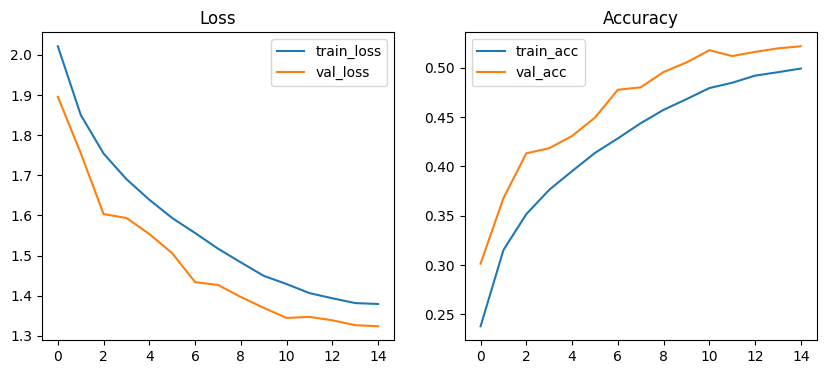

Best validation accuracy: 0.5217


In [37]:
# ---------------------------
# Plot metrics
# ---------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="train_acc")
plt.plot(val_accs, label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

print("Best validation accuracy:", best_val_acc)

In [38]:
# look at visualizations

# load saved models if needed
#state = torch.load("./vit_cifar/best_vit.pth", map_location='cpu')
#model.load_state_dict(state["model_state"])

model.eval()
# set return attention flag to true
model._return_attn = True

# get images and labels
imgs, labels = next(iter(test_loader))
# select imgs array
img = imgs[0:10].to(device)

# get attention maps
with torch.no_grad():
    logits, attn_maps = model(img)

# get predictions
with torch.no_grad():
    predictions = logits.argmax(1)


# print predictions vs actual labels
print(f"Predicted: {predictions.cpu().numpy()}")
print(f"Actual: {labels.numpy()[0:10]}")


Predicted: [3 8 8 0 6 6 1 6 6 1]
Actual: [3 8 8 0 6 6 1 6 3 1]


The below code was modified for the expanding attention project
- Edited by Cole Drumheller

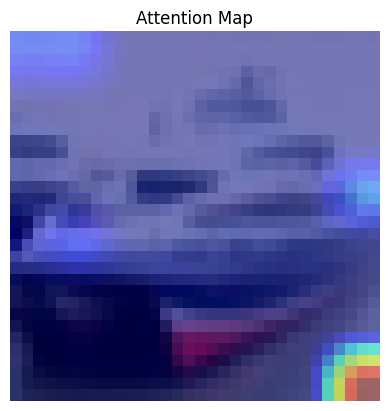

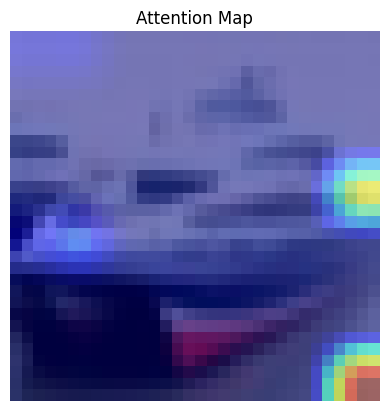

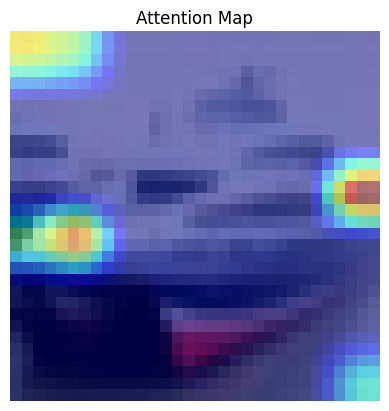

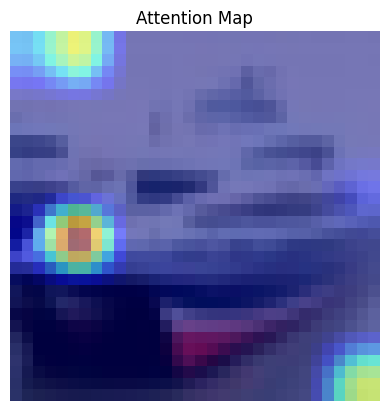

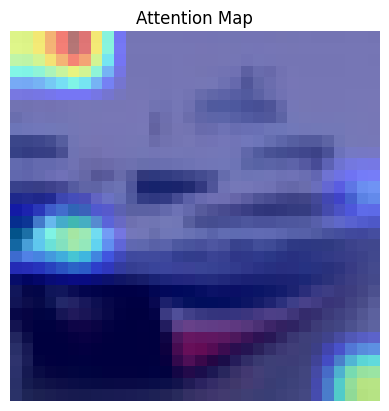

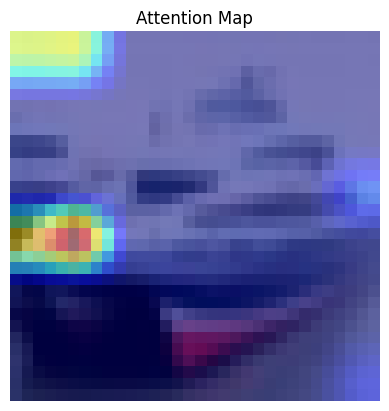

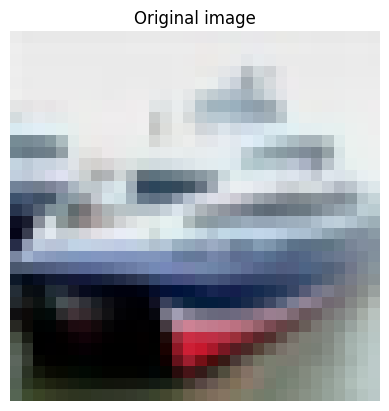

In [44]:
img_num = 1 # select which image you want to look at

# denormalize the image to display it
def denorm(x):
    mean = torch.tensor((0.5, 0.5, 0.5), device=x.device).view(3,1,1)
    std = torch.tensor((0.5, 0.5, 0.5), device = x.device).view(3,1,1)
    return x * std + mean

for i in range(num_layers):
    cls_attn = attn_maps[i][img_num,:,0,1:] # [-1] grabs final layer of attention values, [img#, all heads (:), cls token distribution (0), skip over cls token in keys (1:)]
    num_patches = (img_size // patch_size) ** 2
    grid_size = int(math.sqrt(num_patches))
    cls_attn_map = cls_attn.mean(0).reshape(grid_size, grid_size)
    cls_attn_map = cls_attn_map / cls_attn_map.max()

    # resize the attention map to fit on the image
    attn_resized = F.interpolate(
        cls_attn_map.unsqueeze(0).unsqueeze(0),
        size=(img_size, img_size),
        mode='bilinear'
    )[0,0].cpu()



    img_vis = denorm(img[img_num]).permute(1,2,0).cpu()

   

    # plot the original image with the attention overlay
    plt.imshow(img_vis)
    plt.imshow(attn_resized, cmap='jet', alpha=0.5)
    plt.title('Attention Map')
    plt.axis('off')
    plt.show()

 # plot original image
plt.imshow(img_vis)
plt.title('Original image')
plt.axis('off')
plt.show()
# Red = most attention
# blue = least attention

In [18]:
def objective(trial):
    # sample hyperparameters
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)                 # replaced deprecated suggest_loguniform
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)

    # sample num_heads first
    num_heads = trial.suggest_categorical('num_heads', [4, 6, 8])

    # always sample embed_dim from a fixed (non-dynamic) choice set to satisfy Optuna
    embed_choices = [64, 128, 192, 256]
    embed_dim = trial.suggest_categorical('embed_dim', embed_choices)

    # reject incompatible combos early (avoid building model that will assert)
    if embed_dim % num_heads != 0:
        # return a low score so optimizer avoids this combination
        return 0.0

    depth = trial.suggest_int('depth', 3, 8)
    batch_size = trial.suggest_categorical('batch_size', [64, 128])

    # rebuild model with sampled architecture params (light-weight) -- keep rest of vars from notebook scope
    model_opt = VisionTransformer(img_size=img_size, patch_size=patch_size, in_chans=in_chans, num_classes=num_classes, embed_dim=embed_dim, depth=depth, num_heads=num_heads, mlp_ratio=mlp_ratio, dropout=dropout).to(device)
    criterion_opt = nn.CrossEntropyLoss()
    optimizer_opt = torch.optim.AdamW(model_opt.parameters(), lr=lr, weight_decay=weight_decay)
    # small local dataloaders for tuning (use a subset to speed up)
    sub_train = torch.utils.data.Subset(train_ds, list(range(0, min(2000, len(train_ds)))))
    sub_val = torch.utils.data.Subset(test_ds, list(range(0, min(1000, len(test_ds)))))
    train_loader_opt = DataLoader(sub_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader_opt = DataLoader(sub_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # short training loop (few epochs) and report validation accuracy for pruning
    epochs_tune = 3
    best_val_acc = 0.0
    for ep in range(epochs_tune):
        model_opt.train()
        for imgs, labels in train_loader_opt:
            imgs = imgs.to(device)
            labels = labels.to(device)
            optimizer_opt.zero_grad()
            logits = model_opt(imgs)
            loss = criterion_opt(logits, labels)
            loss.backward()
            optimizer_opt.step()
        # evaluate
        model_opt.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in val_loader_opt:
                imgs = imgs.to(device)
                labels = labels.to(device)
                logits = model_opt(imgs)
                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        trial.report(val_acc, ep)
        # allow pruning
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
    # return best validation accuracy seen
    return best_val_acc

# run study
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20, timeout=None)

print('Best trial:')
print(study.best_trial.params)
# Save best hyperparameters to disk
import json
with open('optuna_best_params.json', 'w') as f:
    json.dump(study.best_trial.params, f, indent=2)


[I 2025-10-21 17:53:53,429] A new study created in memory with name: no-name-12f6b7e4-9721-4760-b9d7-55c2cdfdb1ff
[I 2025-10-21 17:53:53,431] Trial 0 finished with value: 0.0 and parameters: {'lr': 0.0003430957965465738, 'weight_decay': 1.0572433040760063e-05, 'num_heads': 6, 'embed_dim': 64}. Best is trial 0 with value: 0.0.
/Users/joseph/Projects/CSC 702/csc702_fall2025/Transformer/Cole_Joseph/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
[I 2025-10-21 17:55:31,077] Trial 1 finished with value: 0.136 and parameters: {'lr': 0.0033298684870915157, 'weight_decay': 7.393187759776976e-06, 'num_heads': 4, 'embed_dim': 192, 'depth': 8, 'batch_size': 128}. Best is trial 1 with value: 0.136.
[I 2025-10-21 17:57:04,592] Trial 2 finished with value: 0.295 and parameters: {'lr': 0.0009637817934167794, 'weight_decay': 0.000196744977

Best trial:
{'lr': 0.0009637817934167794, 'weight_decay': 0.00019674497706874728, 'num_heads': 8, 'embed_dim': 128, 'depth': 3, 'batch_size': 128}


In [19]:
best_params = {
    'lr': 0.0009637817934167794,
    'weight_decay': 0.00019674497706874728,
    'num_heads': 8,
    'embed_dim': 128,
    'depth': 3,
    'batch_size': 128
}

lr = best_params['lr']
weight_decay = best_params['weight_decay']
num_heads = best_params['num_heads']
embed_dim = best_params['embed_dim']
num_layers = best_params['depth']
batch_size = best_params['batch_size']

# build model and training objects
model = VisionTransformer(
    img_size=img_size,
    patch_size=patch_size,
    in_chans=in_chans,
    num_classes=num_classes,
    embed_dim=embed_dim,
    depth=num_layers,
    num_heads=num_heads,
    mlp_ratio=mlp_ratio,
    dropout=dropout
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
# T_max: total scheduler steps (approx)
steps_per_epoch = max(1, len(train_ds) // batch_size)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * steps_per_epoch)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# training loop
best_val_acc = 0.0
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader, desc=f"Train final {epoch}")
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=total_loss / total, acc=correct / total)

    train_loss = total_loss / total
    train_acc = correct / total

    # validation
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / total
    val_acc = correct / total

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "optuna_params": best_params
        }, os.path.join(save_dir, "best_vit_optuna.pth"))
        print(f"Saved best model (val_acc={best_val_acc:.4f})")

print("Final best validation accuracy:", best_val_acc)


Train final 1:   0%|          | 0/391 [00:00<?, ?it/s]/Users/joseph/Projects/CSC 702/csc702_fall2025/Transformer/Cole_Joseph/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Train final 1: 100%|██████████| 391/391 [01:22<00:00,  4.77it/s, acc=0.3, loss=1.85]   


Epoch 1: train_loss=1.8475 train_acc=0.2997 | val_loss=1.7302 val_acc=0.3428
Saved best model (val_acc=0.3428)


Train final 2: 100%|██████████| 391/391 [01:15<00:00,  5.17it/s, acc=0.431, loss=1.54]


Epoch 2: train_loss=1.5407 train_acc=0.4315 | val_loss=1.3784 val_acc=0.4980
Saved best model (val_acc=0.4980)


Train final 3: 100%|██████████| 391/391 [01:13<00:00,  5.35it/s, acc=0.492, loss=1.4] 


...

Epoch 18: train_loss=0.9132 train_acc=0.6735 | val_loss=0.9060 val_acc=0.6811


Train final 19: 100%|██████████| 391/391 [01:16<00:00,  5.11it/s, acc=0.674, loss=0.905]


Epoch 19: train_loss=0.9052 train_acc=0.6744 | val_loss=0.9010 val_acc=0.6832
Saved best model (val_acc=0.6832)


Train final 20: 100%|██████████| 391/391 [01:15<00:00,  5.20it/s, acc=0.676, loss=0.904]


Epoch 20: train_loss=0.9045 train_acc=0.6755 | val_loss=0.9020 val_acc=0.6826
Final best validation accuracy: 0.6832
